In [6]:
import xarray as xr
import numpy as np

In [71]:
Bell_2D = xr.load_dataset(
    "/mnt/c/Users/banga/OneDrive - University of Southampton/Documents/PhD/CUSTARD analysis/data/glider/processed/Bellamite/Bellamite_2D.nc"
)

In [104]:
def to_pylag_ds(dataset):

    time = dataset["median_TIME"].values
    zi = np.tile(dataset["DEPTH_BIN"].values * -1, (len(time), 1))[
        :, :, np.newaxis, np.newaxis
    ]
    z = zi[:, :-1] - 0.5

    pylag_ds = xr.Dataset(
        {
            "nuh": (
                ("time", "z", "lat", "lon"),
                dataset["dissipation"].values[:, :-1, np.newaxis, np.newaxis],
            ),
            "zeta": (("time", "lat", "lon"), np.full((len(time), 1, 1), np.max(zi))),
        },
        coords={
            "time": (("time"), time),
            "zi": (("time", "zi", "lat", "lon"), zi),
            "z": (("time", "z", "lat", "lon"), z),
            "lat": (("lat"), [-54]),
            "lon": (("lon"), [-89]),
        },
    )
    return pylag_ds


def convert_grid(dataset, dz, dt=3600):

    time = dataset["time"].values
    K = dataset["nuh"].squeeze().values
    zi = dataset["zi"].squeeze().values[0, :]
    z = dataset["z"].squeeze().values[0, :]

    new_time = np.arange(
        np.min(time).astype("datetime64[h]"),
        np.max(time).astype("datetime64[h]"),
        np.timedelta64(dt, "s"),
    )
    new_zi = np.arange(np.min(zi), np.max(zi) + dz, dz)

    temp_K = xr.DataArray(K, coords={"time": time, "z": z})
    new_K = temp_K.interp(time=new_time, z=new_zi, method="linear")

    new_zi = np.tile(new_zi, (len(new_time), 1))[:, :, np.newaxis, np.newaxis]
    new_z = new_zi[:, :-1] + dz / 2

    interp_ds = xr.Dataset(
        {
            "nuh": (
                ("time", "zi", "lat", "lon"),
                new_K.values[:, :, np.newaxis, np.newaxis],
            ),
            "zeta": (
                ("time", "lat", "lon"),
                np.full((len(new_time), 1, 1), np.max(new_zi)),
            ),
        },
        coords={
            "time": (("time"), new_time),
            "zi": (("time", "zi", "lat", "lon"), new_zi),
            "z": (("time", "z", "lat", "lon"), new_z),
            "lat": (("lat"), [-54]),
            "lon": (("lon"), [-89]),
        },
    )

    return interp_ds

In [107]:
test = to_pylag_ds(Bell_2D)
test = convert_grid(test, 1, 7200)
test

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 334, zi: 548, lat: 1, lon: 1, z: 547)
Coordinates:
  * time     (time) datetime64[s] 3kB 2019-12-06T12:00:00 ... 2020-01-03T06:0...
    zi       (time, zi, lat, lon) float64 1MB -546.0 -545.0 -544.0 ... 0.0 1.0
  * lat      (lat) int64 8B -54
  * lon      (lon) int64 8B -89
    z        (time, z, lat, lon) float64 1MB -545.5 -544.5 -543.5 ... -0.5 0.5
Data variables:
    nuh      (time, zi, lat, lon) float64 1MB nan nan nan ... 1.309e-06 nan nan
    zeta     (time, lat, lon) float64 3kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0

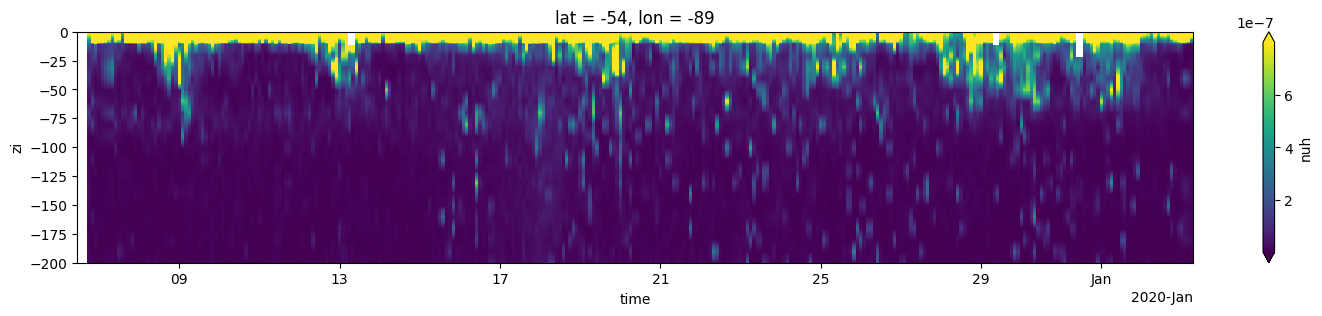

In [109]:
test["nuh"].squeeze().plot.pcolormesh(
    x="time", y="zi", robust=True, ylim=(-200, 0), figsize=(18, 3)
)